In [25]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import math

In [26]:
class CNNAttention(nn.Module):
    def __init__(self, in_channels, num_classes, attn_type="dot", device="cuda"):
        super(CNNAttention, self).__init__()
        channels = [32, 64, 64, 64]
        attn_dim = 32
        self.attn_type = attn_type
        self.conv1 = nn.Conv2d(in_channels = in_channels, out_channels = channels[0], kernel_size = 3, padding = 1)
        #self.pool = nn.MaxPool2d(kernel_size = 2, stride = 2)
        self.conv2 = nn.Conv2d(in_channels = channels[0], out_channels = channels[1], kernel_size = 3, padding = 1)
        self.conv3 = nn.Conv2d(in_channels = channels[1], out_channels = channels[2], kernel_size = 3, padding = 1)
        self.conv4 = nn.Conv2d(in_channels = channels[2], out_channels = channels[3], kernel_size = 3, padding = 1)
        self.fc1 = nn.Linear( channels[-1] , num_classes)

        self.attn_key = nn.Parameter(torch.randn((attn_dim, 1), device=device))

        self.W_q = nn.Linear(channels[-1], attn_dim) # Query transformation
        self.W_v = nn.Linear(channels[-1], channels[-1]) # Value transformation
    
    def cosine_similarity_attention(self, x):
        # x: [B, L, C]
        q = self.W_q(x)  # [B, L, H]
        v = self.W_v(x)  # [B, L, H]
        attn_scores = F.cosine_similarity(q, self.attn_key.reshape(1, 1, -1), dim=-1)  # [B, L]
        self.last_attn_mask = attn_scores.detach()
        attn_probs = torch.softmax(attn_scores, dim=1)  # [B, L]
        output = torch.matmul(attn_probs.unsqueeze(1), v).squeeze(1)  # [B, H]
        return output  # [B, H]

    def dot_product_attention(self, x):
        # x: [B, L, C]
        q = self.W_q(x)  # [B, L, H]
        v = self.W_v(x)  # [B, L, H]

        attn_scores = torch.matmul(q, self.attn_key) / math.sqrt(q.size(-1))  # [B, L, 1]
        self.last_attn_mask = attn_scores.detach().squeeze(-1)
        attn_probs = torch.softmax(attn_scores, dim=1)  # [B, L, 1]

        output = torch.matmul(attn_probs.transpose(1, 2), v).squeeze(1)  # [B, H]
        return output  # [B, H]

    def forward(self, x):  # (batch, rgb, width, height)
        x = self.conv1(x).relu()
        x = self.conv2(x).relu()
        x = self.conv3(x).relu()
        x = self.conv4(x).relu()
        #x = self.pool(x)
        x = x.flatten(2).transpose(1, 2)
        if self.attn_type == "dot":
            x = self.dot_product_attention(x)
        if self.attn_type == "cos":
            x = self.cosine_similarity_attention(x)
        x = self.fc1(x)
        return x


In [27]:
class CNNBaseline(nn.Module):
    def __init__(self, in_channels=3, num_classes=10):
        super(CNNBaseline, self).__init__()
        channels = [32, 64, 64, 64]

        self.conv1 = nn.Conv2d(in_channels, channels[0], kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(channels[0], channels[1], kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(channels[1], channels[2], kernel_size=3, padding=1)
        self.conv4 = nn.Conv2d(channels[2], channels[3], kernel_size=3, padding=1)

        self.pool = nn.MaxPool2d(2, 2)

        # After 4 pooling layers: 32x32 -> 16x16 -> 8x8
        self.fc1 = nn.Linear(channels[-1] * 8 * 8, num_classes)

    def forward(self, x):# Pool twice, similar to VGG16 and RESNET (resnet does it once and does stride = 2)
        x = self.conv1(x).relu()
        x = self.pool(x)
        x = self.conv2(x).relu()
        x = self.conv3(x).relu()
        x = self.pool(x)
        x = self.conv4(x).relu()

        x = x.view(x.size(0), -1)  # Flatten
        x = self.fc1(x)
        return x

In [28]:
class CNNGlobalPooling(nn.Module):
    def __init__(self, in_channels=3, num_classes=10):
        super(CNNGlobalPooling, self).__init__()
        channels = [32, 64, 64, 64]

        self.conv1 = nn.Conv2d(in_channels, channels[0], kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(channels[0], channels[1], kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(channels[1], channels[2], kernel_size=3, padding=1)
        self.conv4 = nn.Conv2d(channels[2], channels[3], kernel_size=3, padding=1)

        self.pool = nn.MaxPool2d(2, 2)

        self.fc1 = nn.Linear(channels[-1], num_classes)

    def forward(self, x):# Pool twice, similar to VGG16 and RESNET (resnet does it once and does stride = 2)
        x = self.conv1(x).relu()
        x = self.pool(x)
        x = self.conv2(x).relu()
        x = self.conv3(x).relu()
        x = self.pool(x)
        x = self.conv4(x).relu()

        x = F.adaptive_avg_pool2d(x, (1, 1))
        x = x.view(x.size(0), -1)
        return self.fc1(x)

In [29]:
import torchvision
import torchvision.transforms as transforms
import torch

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=64, shuffle=True, num_workers=2)

testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=100, shuffle=False, num_workers=2)


In [30]:

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

baseline_model = CNNBaseline(in_channels=3, num_classes=10).to(device)
global_pooling_model = CNNGlobalPooling(in_channels=3, num_classes=10).to(device)
dot_model = CNNAttention(in_channels=3, num_classes=10, attn_type="dot", device=device).to(device)
cos_model = CNNAttention(in_channels=3, num_classes=10, attn_type="cos", device=device).to(device)

criterion = nn.CrossEntropyLoss()
baseline_optimizer = torch.optim.Adam(baseline_model.parameters(), lr=0.001)
global_pooling_optimizer = torch.optim.Adam(global_pooling_model.parameters(), lr=0.001)
dot_optimizer = torch.optim.Adam(dot_model.parameters(), lr=0.001)
cos_optimizer = torch.optim.Adam(cos_model.parameters(), lr=0.001)


In [31]:
best_accuracy = 0
def eval_model(model, epoch, save_path="model"):
    global best_accuracy
    if epoch == 1: 
        best_accuracy = 0
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for inputs, labels in testloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    accuracy = 100 * correct / total
    print(f"Accuracy on test images: {accuracy:.2f}%")
    if accuracy > best_accuracy:
        best_accuracy = accuracy
        torch.save(model.state_dict(), f"{save_path}.pth")
        print(f"New best model saved with accuracy: {accuracy:.2f}%")


In [32]:
def train(model, optim, loss_history, epochs=100, save_path="model"):
    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        count = 0 

        for i, (inputs, labels) in enumerate(trainloader):
            inputs, labels = inputs.to(device), labels.to(device)

            optim.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optim.step()

            running_loss += loss.item()
            count += 1

            running_loss += loss.item()
        avg_loss = running_loss / count
        loss_history.append(avg_loss)
        print(f"Epoch [{epoch+1}] Loss: {avg_loss:.4f}")
        eval_model(model, epoch+1, save_path)


In [ ]:
baseline_loss_history = []
global_pooling_loss_history = []
dot_loss_history = []
cos_loss_history = []

train(baseline_model, baseline_optimizer, baseline_loss_history, epochs=100, save_path="baseline_model")
train(global_pooling_model, global_pooling_optimizer, global_pooling_loss_history, epochs=100, save_path="global_pooling_model")
train(dot_model, dot_optimizer, dot_loss_history, epochs=100, save_path="dot_model")
train(cos_model, cos_optimizer, cos_loss_history, epochs=100, save_path="cos_model")

In [34]:
baseline_model.load_state_dict(torch.load("baseline_model.pth"))
global_pooling_model.load_state_dict(torch.load("global_pooling_model.pth"))
dot_model.load_state_dict(torch.load("dot_model.pth"))
cos_model.load_state_dict(torch.load("cos_model.pth"))

<All keys matched successfully>

In [35]:
import numpy as np
from torch.utils.data import Subset

def create_stratified_subset(dataset, num_samples_per_class, seed=42):
    rng = np.random.RandomState(seed)
    targets = np.array(dataset.targets)
    num_classes = len(dataset.classes)
    
    subset_indices = []
    for class_idx in range(num_classes):
        # Get all indices for this class
        class_indices = np.where(targets == class_idx)[0]
        
        # Ensure we don't exceed available samples
        n_samples = min(num_samples_per_class, len(class_indices))
        
        # Randomly select indices without replacement
        selected = rng.choice(class_indices, size=n_samples, replace=False)
        subset_indices.extend(selected)
    
    # Shuffle indices to mix classes
    rng.shuffle(subset_indices)
    
    return Subset(dataset, subset_indices)

In [36]:
test_subset = create_stratified_subset(testset, num_samples_per_class=50)
testloader_small = torch.utils.data.DataLoader(
    test_subset,
    batch_size=100,
    shuffle=False,
    num_workers=2
)

In [37]:
from captum.attr import GradientShap

def apply_shap(model, device='cuda'):
    model.eval()
    model.to(device)

    gradient_shap = GradientShap(model)

    # choose 20 random baseline samples from training set
    idx = torch.randperm(len(trainset))[:20]
    baselines = torch.stack([trainset[i][0] for i in idx]).to(device)  # shape [20,3,32,32]

    for i, (inputs, labels) in enumerate(testloader_small):
        inputs, labels = inputs.to(device), labels.to(device)

        attributions = gradient_shap.attribute(
            inputs=inputs,
            baselines=baselines,          # <-- tensor of multiple baselines
            n_samples=50,                 # more samples improves stability
            stdevs=0.1,
            target=labels
        )

        # attributions shape: [batch, 3, 32, 32]
        yield attributions, inputs, labels


In [38]:
import torch
import torch.nn.functional as F
from collections import defaultdict

def compute_entropy(heatmap, eps=1e-12):
    """Compute entropy of flattened normalized heatmap."""
    p = heatmap.abs().flatten()
    p = p / (p.sum() + eps)
    return -(p * torch.log(p + eps)).sum()


def compare_attributions(iterA, iterB, num_classes=10):
    """
    Compare two models' SHAP attributions for a paper.

    iterA, iterB = iterators that yield tuples:
        (attributions, inputs, labels)

    Returns: dictionary of metrics.
    """

    stats = defaultdict(list)
    class_stats = {c: defaultdict(list) for c in range(num_classes)}

    for (attrA, inputsA, labelsA), (attrB, inputsB, labelsB) in zip(iterA, iterB):

        # safety check: ensure identical labels + batch sizes
        assert torch.equal(labelsA, labelsB), "Label mismatch between iterators"
        assert attrA.shape == attrB.shape, "Different attribution shapes"

        batch_size = attrA.size(0)

        # Compute per-sample stats
        for i in range(batch_size):
            a = attrA[i]
            b = attrB[i]
            lbl = labelsA[i].item()

            # Heatmaps
            a_hm = a.abs().sum(dim=0)
            b_hm = b.abs().sum(dim=0)

            # ---- Basic magnitudes ----
            stats["mean_abs_A"].append(a.abs().mean().item())
            stats["mean_abs_B"].append(b.abs().mean().item())

            stats["mean_signed_A"].append(a.mean().item())
            stats["mean_signed_B"].append(b.mean().item())

            # ---- Sparsity (L1/L2) ----
            stats["sparsity_A"].append(
                a.abs().sum().item() / (torch.sqrt((a**2).sum()) + 1e-8)
            )
            stats["sparsity_B"].append(
                b.abs().sum().item() / (torch.sqrt((b**2).sum()) + 1e-8)
            )

            # ---- Entropy ----
            stats["entropy_A"].append(compute_entropy(a_hm).item())
            stats["entropy_B"].append(compute_entropy(b_hm).item())

            # ---- Cosine similarity between models ----
            a_flat = a.flatten()
            b_flat = b.flatten()
            cos = F.cosine_similarity(a_flat.unsqueeze(0), b_flat.unsqueeze(0)).item()
            stats["cos_sim"].append(cos)

            # ---- Pixelwise correlation ----
            corr = torch.corrcoef(torch.stack([a_flat, b_flat]))[0, 1].item()
            stats["corr"].append(corr)

            # ---- Class-wise statistics ----
            class_stats[lbl]["mean_abs_A"].append(a.abs().mean().item())
            class_stats[lbl]["mean_abs_B"].append(b.abs().mean().item())
            class_stats[lbl]["entropy_A"].append(compute_entropy(a_hm).item())
            class_stats[lbl]["entropy_B"].append(compute_entropy(b_hm).item())
            class_stats[lbl]["cos_sim"].append(cos)
            class_stats[lbl]["corr"].append(corr)

    # Aggregate everything into final metrics
    final_stats = {
        "overall": {k: float(torch.tensor(v).mean()) for k, v in stats.items()},
        "class_wise": {
            c: {k: float(torch.tensor(v).mean()) for k, v in cls_dict.items()}
            for c, cls_dict in class_stats.items()
        },
        "counts": {
            "num_samples evaluated": sum(len(v) for v in stats.values()) // len(stats)
        }
    }
    return final_stats


In [39]:
import torch
import torch.nn.functional as F
from collections import defaultdict

def compare_attributions_with_deletion(k=0.2, num_classes=10):
    iterA = apply_shap(baseline_model)
    iterB = apply_shap(global_pooling_model)
    iterC = apply_shap(cos_model)
    iterD = apply_shap(dot_model)

    modelA = baseline_model
    modelB = global_pooling_model
    modelC = cos_model
    modelD = dot_model
    modelA.eval()
    modelB.eval()
    modelC.eval()
    modelD.eval()

    device = next(modelA.parameters()).device

    stats = defaultdict(list)
    class_stats = {c: defaultdict(list) for c in range(num_classes)}

    with torch.no_grad():

        for (attrA, inputsA, labelsA), (attrB, inputsB, labelsB) in zip(iterA, iterB, iterC, iterD):

            assert torch.equal(labelsA, labelsB)
            assert attrA.shape == attrB.shape

            inputsA = inputsA.to(device)
            inputsB = inputsB.to(device)
            labelsA = labelsA.to(device)

            batch_size = attrA.size(0)

            # Baseline predictions
            logitsA_base = modelA(inputsA)
            logitsB_base = modelB(inputsB)

            probsA_base = F.softmax(logitsA_base, dim=1)
            probsB_base = F.softmax(logitsB_base, dim=1)

            predsA_base = probsA_base.argmax(dim=1)
            predsB_base = probsB_base.argmax(dim=1)

            for i in range(batch_size):
                a = attrA[i].to(device)
                b = attrB[i].to(device)
                xA = inputsA[i].clone()
                xB = inputsB[i].clone()

                lbl = labelsA[i].item()

                # ---- compute heatmaps ----
                a_hm = a.abs().sum(dim=0)   # (H, W)
                b_hm = b.abs().sum(dim=0)

                # ---- flatten heatmaps ----
                H, W = a_hm.shape
                num_pixels = H * W
                k_pixels = int(k * num_pixels)

                # ---- find top-k attributed pixels ----
                _, idxA = torch.topk(a_hm.flatten(), k_pixels)
                _, idxB = torch.topk(b_hm.flatten(), k_pixels)

                # ---- mask these pixels (set to zero) ----
                xA_flat = xA.view(3, -1)
                xB_flat = xB.view(3, -1)

                xA_flat[:, idxA] = 0
                xB_flat[:, idxB] = 0

                xA_masked = xA_flat.view_as(inputsA[i])
                xB_masked = xB_flat.view_as(inputsB[i])

                # ---- run models on masked inputs ----
                logitA_del = modelA(xA_masked.unsqueeze(0))
                logitB_del = modelB(xB_masked.unsqueeze(0))

                probA_del = F.softmax(logitA_del, dim=1)[0]
                probB_del = F.softmax(logitB_del, dim=1)[0]

                predA_del = probA_del.argmax().item()
                predB_del = probB_del.argmax().item()

                # ---- deletion accuracy ----
                stats["deletion_acc_A"].append(int(predA_del == labelsA[i].item()))
                stats["deletion_acc_B"].append(int(predB_del == labelsA[i].item()))

                # ---- confidence drop (target class or predicted class) ----
                base_conf_A = probsA_base[i, labelsA[i]].item()
                base_conf_B = probsB_base[i, labelsA[i]].item()

                del_conf_A = probA_del[labelsA[i]].item()
                del_conf_B = probB_del[labelsA[i]].item()

                stats["conf_drop_A"].append(base_conf_A - del_conf_A)
                stats["conf_drop_B"].append(base_conf_B - del_conf_B)

                # ---- keep your existing metrics ----

                # Basic magnitudes
                stats["mean_abs_A"].append(a.abs().mean().item())
                stats["mean_abs_B"].append(b.abs().mean().item())

                stats["mean_signed_A"].append(a.mean().item())
                stats["mean_signed_B"].append(b.mean().item())

                # Sparsity
                stats["sparsity_A"].append(
                    a.abs().sum().item() / (torch.sqrt((a**2).sum()) + 1e-8)
                )
                stats["sparsity_B"].append(
                    b.abs().sum().item() / (torch.sqrt((b**2).sum()) + 1e-8)
                )

                # Entropy
                stats["entropy_A"].append(compute_entropy(a_hm).item())
                stats["entropy_B"].append(compute_entropy(b_hm).item())

                # Cosine sim
                a_flat = a.flatten()
                b_flat = b.flatten()
                cos = F.cosine_similarity(a_flat.unsqueeze(0), b_flat.unsqueeze(0)).item()
                stats["cos_sim"].append(cos)

                # Pixelwise correlation
                corr = torch.corrcoef(torch.stack([a_flat, b_flat]))[0, 1].item()
                stats["corr"].append(corr)

                # class-wise entries
                class_stats[lbl]["deletion_acc_A"].append(int(predA_del == labelsA[i]))
                class_stats[lbl]["deletion_acc_B"].append(int(predB_del == labelsA[i]))

                class_stats[lbl]["conf_drop_A"].append(base_conf_A - del_conf_A)
                class_stats[lbl]["conf_drop_B"].append(base_conf_B - del_conf_B)

                class_stats[lbl]["entropy_A"].append(compute_entropy(a_hm).item())
                class_stats[lbl]["entropy_B"].append(compute_entropy(b_hm).item())
                class_stats[lbl]["cos_sim"].append(cos)
                class_stats[lbl]["corr"].append(corr)

    # aggregate
    final_stats = {
        "overall": {
            k: float(torch.tensor(v, dtype=torch.float32).mean())
            for k, v in stats.items()
        },
        "class_wise": {
            c: {
                k: float(torch.tensor(v, dtype=torch.float32).mean())
                for k, v in cls_dict.items()
            }
            for c, cls_dict in class_stats.items()
        },
        "counts": {"num_samples_evaluated": len(stats["mean_abs_A"])}
    }
    return final_stats  


In [48]:
def compare_attributions_with_deletion(k=0.2, num_classes=10):
    """
    Compare attribution methods across all four models with model-specific naming.
    This version maintains the original structure but uses proper model names.
    """
    
    # Get SHAP attributions for all models
    iter_baseline = apply_shap(baseline_model)
    iter_global_pooling = apply_shap(global_pooling_model)
    iter_cos = apply_shap(cos_model)
    iter_dot = apply_shap(dot_model)

    # Set all models to evaluation mode
    baseline_model.eval()
    global_pooling_model.eval()
    cos_model.eval()
    dot_model.eval()

    device = next(baseline_model.parameters()).device

    # Initialize statistics dictionaries with model-specific names
    stats = defaultdict(list)
    class_stats = {c: defaultdict(list) for c in range(num_classes)}

    with torch.no_grad():
        # Iterate through all model iterations in parallel
        for (attr_baseline, inputs_baseline, labels_baseline), \
            (attr_global_pooling, inputs_global_pooling, labels_global_pooling), \
            (attr_cos, inputs_cos, labels_cos), \
            (attr_dot, inputs_dot, labels_dot) in zip(iter_baseline, iter_global_pooling, iter_cos, iter_dot):

            # Ensure all labels are the same across models
            assert torch.equal(labels_baseline, labels_global_pooling)
            assert torch.equal(labels_baseline, labels_cos)
            assert torch.equal(labels_baseline, labels_dot)
            
            # Ensure attribution shapes are consistent
            assert attr_baseline.shape == attr_global_pooling.shape
            assert attr_baseline.shape == attr_cos.shape
            assert attr_baseline.shape == attr_dot.shape

            # Move data to device
            inputs_baseline = inputs_baseline.to(device)
            inputs_global_pooling = inputs_global_pooling.to(device)
            inputs_cos = inputs_cos.to(device)
            inputs_dot = inputs_dot.to(device)
            labels = labels_baseline.to(device)

            batch_size = attr_baseline.size(0)

            # Get baseline predictions for all models
            logits_baseline = baseline_model(inputs_baseline)
            logits_global_pooling = global_pooling_model(inputs_global_pooling)
            logits_cos = cos_model(inputs_cos)
            logits_dot = dot_model(inputs_dot)

            probs_baseline = F.softmax(logits_baseline, dim=1)
            probs_global_pooling = F.softmax(logits_global_pooling, dim=1)
            probs_cos = F.softmax(logits_cos, dim=1)
            probs_dot = F.softmax(logits_dot, dim=1)

            preds_baseline = probs_baseline.argmax(dim=1)
            preds_global_pooling = probs_global_pooling.argmax(dim=1)
            preds_cos = probs_cos.argmax(dim=1)
            preds_dot = probs_dot.argmax(dim=1)

            # Process each sample in the batch
            for i in range(batch_size):
                # Get attributions and inputs for each model
                attr_b = attr_baseline[i].to(device)
                attr_gp = attr_global_pooling[i].to(device)
                attr_c = attr_cos[i].to(device)
                attr_d = attr_dot[i].to(device)
                
                x_b = inputs_baseline[i].clone()
                x_gp = inputs_global_pooling[i].clone()
                x_c = inputs_cos[i].clone()
                x_d = inputs_dot[i].clone()

                lbl = labels[i].item()

                # Compute heatmaps for all models
                hm_b = attr_b.abs().sum(dim=0)
                hm_gp = attr_gp.abs().sum(dim=0)
                hm_c = attr_c.abs().sum(dim=0)
                hm_d = attr_d.abs().sum(dim=0)

                # Get dimensions and calculate pixels to delete
                H, W = hm_b.shape
                num_pixels = H * W
                k_pixels = int(k * num_pixels)

                # Process baseline model
                _, idx_b = torch.topk(hm_b.flatten(), k_pixels)
                x_b_flat = x_b.view(3, -1)
                x_b_flat[:, idx_b] = 0
                x_b_masked = x_b_flat.view_as(inputs_baseline[i])
                
                logit_b_del = baseline_model(x_b_masked.unsqueeze(0))
                prob_b_del = F.softmax(logit_b_del, dim=1)[0]
                pred_b_del = prob_b_del.argmax().item()

                # Process global_pooling model
                _, idx_gp = torch.topk(hm_gp.flatten(), k_pixels)
                x_gp_flat = x_gp.view(3, -1)
                x_gp_flat[:, idx_gp] = 0
                x_gp_masked = x_gp_flat.view_as(inputs_global_pooling[i])
                
                logit_gp_del = global_pooling_model(x_gp_masked.unsqueeze(0))
                prob_gp_del = F.softmax(logit_gp_del, dim=1)[0]
                pred_gp_del = prob_gp_del.argmax().item()

                # Process cos model
                _, idx_c = torch.topk(hm_c.flatten(), k_pixels)
                x_c_flat = x_c.view(3, -1)
                x_c_flat[:, idx_c] = 0
                x_c_masked = x_c_flat.view_as(inputs_cos[i])
                
                logit_c_del = cos_model(x_c_masked.unsqueeze(0))
                prob_c_del = F.softmax(logit_c_del, dim=1)[0]
                pred_c_del = prob_c_del.argmax().item()

                # Process dot model
                _, idx_d = torch.topk(hm_d.flatten(), k_pixels)
                x_d_flat = x_d.view(3, -1)
                x_d_flat[:, idx_d] = 0
                x_d_masked = x_d_flat.view_as(inputs_dot[i])
                
                logit_d_del = dot_model(x_d_masked.unsqueeze(0))
                prob_d_del = F.softmax(logit_d_del, dim=1)[0]
                pred_d_del = prob_d_del.argmax().item()

                # Collect deletion accuracies
                stats["deletion_acc_baseline"].append(int(pred_b_del == lbl))
                stats["deletion_acc_global_pooling"].append(int(pred_gp_del == lbl))
                stats["deletion_acc_cos"].append(int(pred_c_del == lbl))
                stats["deletion_acc_dot"].append(int(pred_d_del == lbl))

                # Collect confidence drops
                base_conf_b = probs_baseline[i, labels[i]].item()
                base_conf_gp = probs_global_pooling[i, labels[i]].item()
                base_conf_c = probs_cos[i, labels[i]].item()
                base_conf_d = probs_dot[i, labels[i]].item()

                del_conf_b = prob_b_del[labels[i]].item()
                del_conf_gp = prob_gp_del[labels[i]].item()
                del_conf_c = prob_c_del[labels[i]].item()
                del_conf_d = prob_d_del[labels[i]].item()

                stats["conf_drop_baseline"].append(base_conf_b - del_conf_b)
                stats["conf_drop_global_pooling"].append(base_conf_gp - del_conf_gp)
                stats["conf_drop_cos"].append(base_conf_c - del_conf_c)
                stats["conf_drop_dot"].append(base_conf_d - del_conf_d)

                # Basic magnitudes
                stats["mean_abs_baseline"].append(attr_b.abs().mean().item())
                stats["mean_abs_global_pooling"].append(attr_gp.abs().mean().item())
                stats["mean_abs_cos"].append(attr_c.abs().mean().item())
                stats["mean_abs_dot"].append(attr_d.abs().mean().item())

                stats["mean_signed_baseline"].append(attr_b.mean().item())
                stats["mean_signed_global_pooling"].append(attr_gp.mean().item())
                stats["mean_signed_cos"].append(attr_c.mean().item())
                stats["mean_signed_dot"].append(attr_d.mean().item())

                # Sparsity
                stats["sparsity_baseline"].append(
                    attr_b.abs().sum().item() / (torch.sqrt((attr_b**2).sum()) + 1e-8)
                )
                stats["sparsity_global_pooling"].append(
                    attr_gp.abs().sum().item() / (torch.sqrt((attr_gp**2).sum()) + 1e-8)
                )
                stats["sparsity_cos"].append(
                    attr_c.abs().sum().item() / (torch.sqrt((attr_c**2).sum()) + 1e-8)
                )
                stats["sparsity_dot"].append(
                    attr_d.abs().sum().item() / (torch.sqrt((attr_d**2).sum()) + 1e-8)
                )

                # Entropy
                stats["entropy_baseline"].append(compute_entropy(hm_b).item())
                stats["entropy_global_pooling"].append(compute_entropy(hm_gp).item())
                stats["entropy_cos"].append(compute_entropy(hm_c).item())
                stats["entropy_dot"].append(compute_entropy(hm_d).item())

                # Cross-model comparisons
                attr_list = [attr_b, attr_gp, attr_c, attr_d]
                model_names = ['baseline', 'global_pooling', 'cos', 'dot']
                
                for j in range(len(attr_list)):
                    for n in range(j+1, len(attr_list)):
                        attr1_flat = attr_list[j].flatten()
                        attr2_flat = attr_list[n].flatten()
                        
                        model1_name = model_names[j]
                        model2_name = model_names[n]
                        
                        # Cosine similarity
                        cos_sim = F.cosine_similarity(attr1_flat.unsqueeze(0), attr2_flat.unsqueeze(0)).item()
                        stats[f"cos_sim_{model1_name}_{model2_name}"].append(cos_sim)
                        
                        # Pixelwise correlation
                        corr = torch.corrcoef(torch.stack([attr1_flat, attr2_flat]))[0, 1].item()
                        stats[f"corr_{model1_name}_{model2_name}"].append(corr)

                # Class-wise entries
                class_stats[lbl]["deletion_acc_baseline"].append(int(pred_b_del == lbl))
                class_stats[lbl]["deletion_acc_global_pooling"].append(int(pred_gp_del == lbl))
                class_stats[lbl]["deletion_acc_cos"].append(int(pred_c_del == lbl))
                class_stats[lbl]["deletion_acc_dot"].append(int(pred_d_del == lbl))

                class_stats[lbl]["conf_drop_baseline"].append(base_conf_b - del_conf_b)
                class_stats[lbl]["conf_drop_global_pooling"].append(base_conf_gp - del_conf_gp)
                class_stats[lbl]["conf_drop_cos"].append(base_conf_c - del_conf_c)
                class_stats[lbl]["conf_drop_dot"].append(base_conf_d - del_conf_d)

                class_stats[lbl]["entropy_baseline"].append(compute_entropy(hm_b).item())
                class_stats[lbl]["entropy_global_pooling"].append(compute_entropy(hm_gp).item())
                class_stats[lbl]["entropy_cos"].append(compute_entropy(hm_c).item())
                class_stats[lbl]["entropy_dot"].append(compute_entropy(hm_d).item())

                # Cross-model comparisons for class-wise
                for j in range(len(attr_list)):
                    for m in range(j+1, len(attr_list)):
                        attr1_flat = attr_list[j].flatten()
                        attr2_flat = attr_list[m].flatten()
                        
                        model1_name = model_names[j]
                        model2_name = model_names[m]
                        
                        cos_sim = F.cosine_similarity(attr1_flat.unsqueeze(0), attr2_flat.unsqueeze(0)).item()
                        corr = torch.corrcoef(torch.stack([attr1_flat, attr2_flat]))[0, 1].item()
                        
                        class_stats[lbl][f"cos_sim_{model1_name}_{model2_name}"].append(cos_sim)
                        class_stats[lbl][f"corr_{model1_name}_{model2_name}"].append(corr)

    # Aggregate final statistics
    final_stats = {
        "overall": {
            k: float(torch.tensor(v, dtype=torch.float32).mean())
            for k, v in stats.items()
        },
        "class_wise": {
            c: {
                k: float(torch.tensor(v, dtype=torch.float32).mean())
                for k, v in cls_dict.items()
            }
            for c, cls_dict in class_stats.items()
        },
        "counts": {"num_samples_evaluated": len(stats["mean_abs_baseline"])}
    }
    
    return final_stats

In [49]:
import json
#final_stats = compare_attributions_with_deletion(apply_shap(baseline_model), apply_shap(global_pooling_model))
final_stats = compare_attributions_with_deletion()
json.dump(final_stats, open("shap_comparison_final.json", "w"), indent=4)

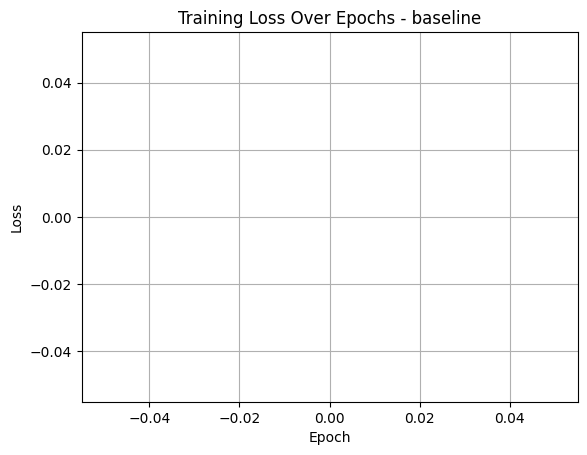

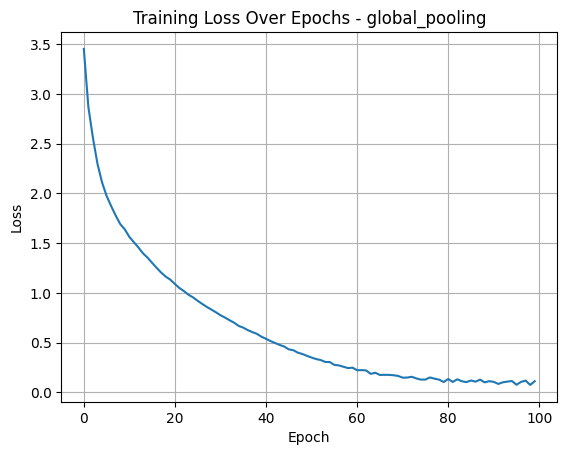

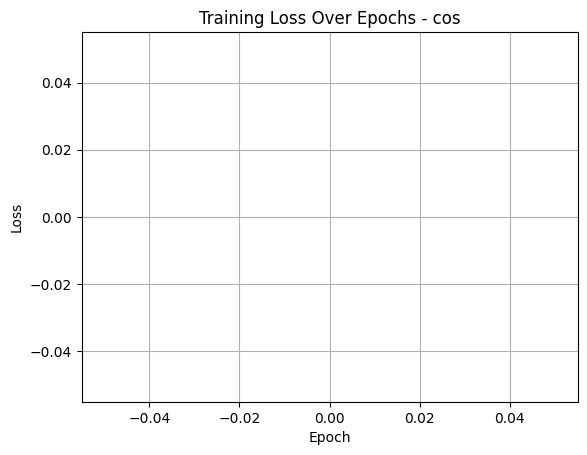

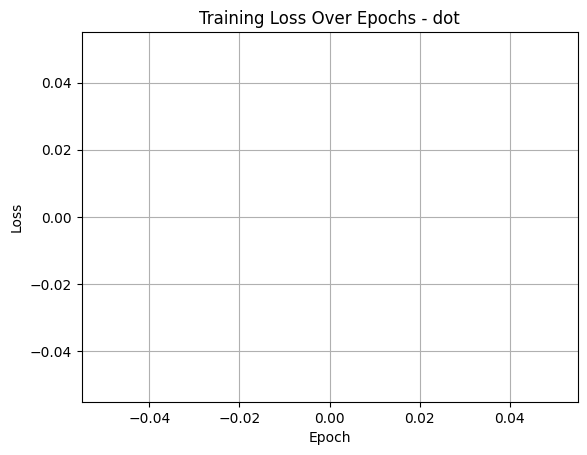

In [ ]:
import matplotlib.pyplot as plt

def plot_loss(loss_histories, model_names):
    plt.figure(figsize=(10, 6))
    
    for history, model_name in zip(loss_histories, model_names):
        plt.plot(history, label=model_name, linewidth=2)
    
    plt.title("Training Loss Comparison - All Models", fontsize=14, fontweight='bold')
    plt.xlabel("Epoch", fontsize=12)
    plt.ylabel("Loss", fontsize=12)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.savefig("loss_comparison.png", dpi=300, bbox_inches="tight")
    plt.show()

plot_loss([baseline_loss_history, global_pooling_loss_history, 
           dot_loss_history, cos_loss_history], 
          ["baseline", "global_pooling", "attention", "cosine_attention"])